# Naive climate-GEA — Kendall-τ on SV Δp (gen3 vs SEEDMIX)

**Model (`build_kendall.py`).** For each non-SNP record:
`τ, p = kendalltau(x, y)` where
- `y` = **Δp** = (gen-3 `site_gen_plot` pool AF) − **p₀** (founding SEEDMIX, mean of 8 reps),
- `x` = each pool's site **temperature** (bio1),
across the **193 gen-3 pools**. Kendall **τ-b** (tie-corrected: pools in a site
share one bio1). Positive τ → allele rises in warm / falls in cold = candidate
climate-adaptive SV. **Naive**: no pseudoreplication/structure correction.

SV = `|alt_len − ref_len| > 50 bp`.


In [1]:
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea")
import lib

GEA = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea"
z = np.load(f"{GEA}/kendall_gen3_bio1.npz", allow_pickle=True)
df = pd.DataFrame({k: z[k] for k in
                   ["chrom","pos","ref_len","alt_len","sv_size","tau","pval","p0","dp_mean"]})
df["chrom"] = df["chrom"].astype(str)
sv = df[df.sv_size > 50].copy()                     # the SV-GEA set
sv = sv[np.isfinite(sv.tau)]
n_tested = len(sv)
bonf = 0.05 / n_tested
print(f"non-SNP records: {len(df):,} | SVs tested (finite τ): {n_tested:,}")
print(f"Bonferroni 0.05/n = {bonf:.2e}  (-log10 = {-np.log10(bonf):.2f})")
sv.head()

non-SNP records: 2,252,583 | SVs tested (finite τ): 226,417
Bonferroni 0.05/n = 2.21e-07  (-log10 = 6.66)


,chrom,pos,ref_len,alt_len,sv_size,tau,pval,p0,dp_mean
0,Chr1,2,1,2161,2160,-0.205436,0.000034,0.050886,0.007305
1,Chr1,2,1,4527,4526,-0.171589,0.000538,0.020640,0.006865
2,Chr1,2,1,2334,2333,0.149802,0.002580,0.003261,0.003923
3,Chr1,2,1,2706,2705,0.085902,0.084081,0.008094,-0.006283
4,Chr1,2,1,4535,4534,-0.055212,0.265657,0.008455,0.003721


## Distributions & inflation (τ, p-values, QQ)

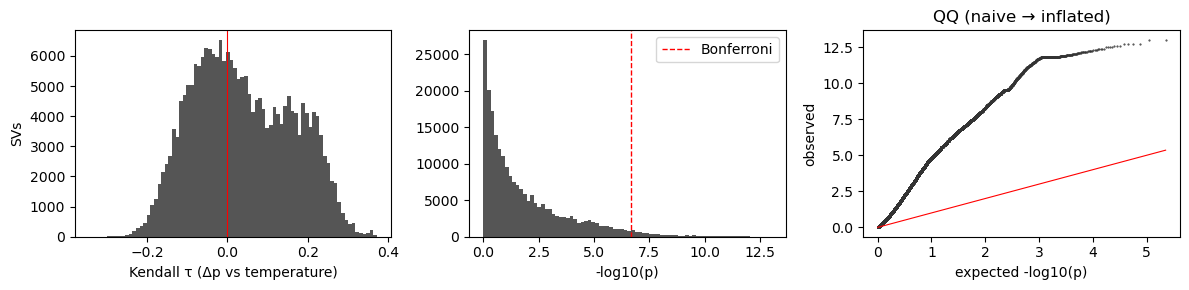

τ>0 & p<0.05: 75,211 | genome-wide (p<Bonferroni): 7,154


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(sv.tau, bins=80, color="#555"); ax[0].axvline(0, color="r", lw=.8)
ax[0].set_xlabel("Kendall τ (Δp vs temperature)"); ax[0].set_ylabel("SVs")
ax[1].hist(np.clip(-np.log10(sv.pval), 0, 14), bins=80, color="#555")
ax[1].axvline(-np.log10(bonf), color="r", lw=1, ls="--", label="Bonferroni")
ax[1].set_xlabel("-log10(p)"); ax[1].legend()
# QQ plot of p-values (inflation under the naive test)
obs = -np.log10(np.sort(sv.pval.values))
exp = -np.log10(np.linspace(1/len(obs), 1, len(obs)))
ax[2].plot(exp, obs, ".", ms=1, color="#333"); ax[2].plot([0,exp.max()],[0,exp.max()],"r-",lw=.8)
ax[2].set_xlabel("expected -log10(p)"); ax[2].set_ylabel("observed"); ax[2].set_title("QQ (naive → inflated)")
plt.tight_layout(); plt.show()
print(f"τ>0 & p<0.05: {((sv.tau>0)&(sv.pval<0.05)).sum():,} | "
      f"genome-wide (p<Bonferroni): {(sv.pval<bonf).sum():,}")

## GWAS-style Manhattan

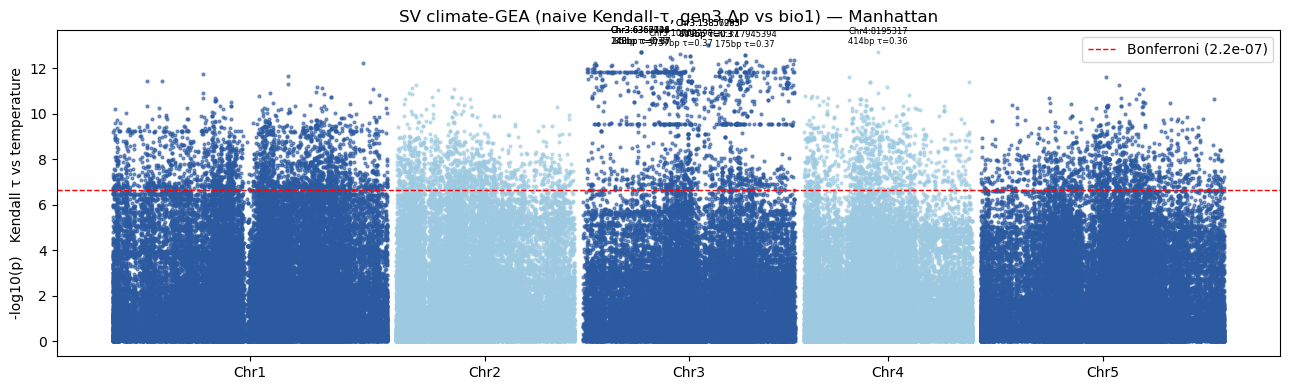

In [3]:
# GWAS-style Manhattan: -log10(p) vs cumulative genomic position, SVs, by chrom.
chrom_order = [f"Chr{i}" for i in range(1, 6)]
sv["chrom"] = pd.Categorical(sv.chrom, chrom_order, ordered=True)
sv = sv.sort_values(["chrom", "pos"])
# cumulative offset per chrom (observed max pos + gap)
off, cum, ticks, tlab = {}, 0, [], []
gap = 1_000_000
for c in chrom_order:
    off[c] = cum
    cmax = sv.loc[sv.chrom == c, "pos"].max()
    ticks.append(cum + cmax/2); tlab.append(c)
    cum += cmax + gap
sv["gpos"] = sv.pos + sv.chrom.map(off).astype(float)
sv["mlogp"] = -np.log10(sv.pval)

fig, ax = plt.subplots(figsize=(13, 4))
cols = {"Chr1":"#2c5aa0", "Chr2":"#9ecae1", "Chr3":"#2c5aa0",
        "Chr4":"#9ecae1", "Chr5":"#2c5aa0"}
for c in chrom_order:
    s = sv[sv.chrom == c]
    ax.scatter(s.gpos, s.mlogp, s=4, color=cols[c], rasterized=True, alpha=.6)
ax.axhline(-np.log10(bonf), color="r", lw=1, ls="--", label=f"Bonferroni ({bonf:.1e})")
# label the few strongest hits
top = sv.nlargest(8, "mlogp")
for _, r in top.iterrows():
    ax.annotate(f"{r.chrom}:{int(r.pos)}\n{int(r.sv_size)}bp τ={r.tau:.2f}",
                (r.gpos, r.mlogp), fontsize=6, ha="center",
                xytext=(0, 6), textcoords="offset points")
ax.set_xticks(ticks); ax.set_xticklabels(tlab)
ax.set_ylabel("-log10(p)   Kendall τ vs temperature")
ax.set_title("SV climate-GEA (naive Kendall-τ, gen3 Δp vs bio1) — Manhattan")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

## Signed Manhattan (direction of selection)

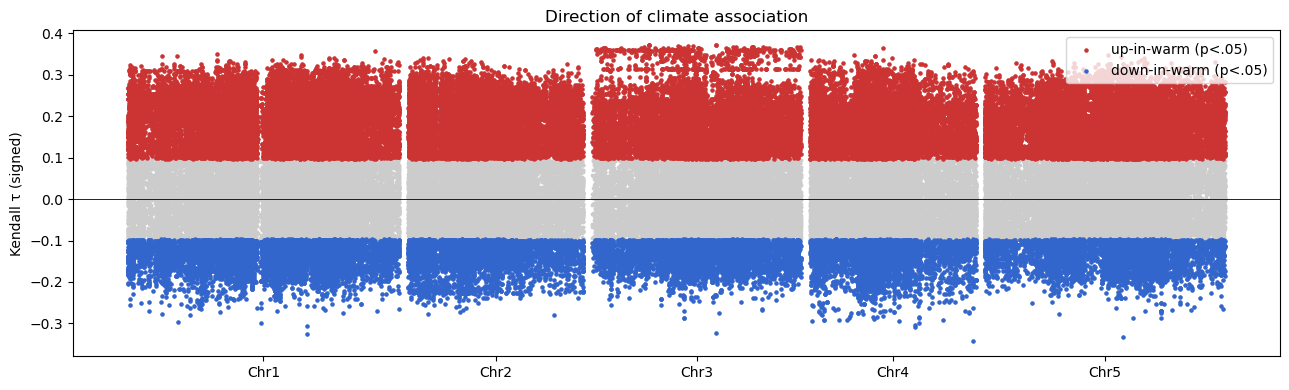

In [4]:
# Signed Manhattan: direction of selection (up-in-warm red / down-in-cold blue).
fig, ax = plt.subplots(figsize=(13, 4))
sig = sv[sv.pval < 0.05]
ax.scatter(sv.gpos, sv.tau, s=3, color="0.8", rasterized=True)
up = sig[sig.tau > 0]; dn = sig[sig.tau < 0]
ax.scatter(up.gpos, up.tau, s=5, color="#c33", rasterized=True, label="up-in-warm (p<.05)")
ax.scatter(dn.gpos, dn.tau, s=5, color="#36c", rasterized=True, label="down-in-warm (p<.05)")
ax.axhline(0, color="k", lw=.6)
ax.set_xticks(ticks); ax.set_xticklabels(tlab)
ax.set_ylabel("Kendall τ (signed)"); ax.set_title("Direction of climate association")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()

## Top candidate SVs

In [5]:
# Top candidate SVs (the poster set is the up-in-warm tail).
cols = ["chrom","pos","ref_len","alt_len","sv_size","tau","pval","p0","dp_mean"]
sv.sort_values("tau", ascending=False)[cols].head(20).reset_index(drop=True)

,chrom,pos,ref_len,alt_len,sv_size,tau,pval,p0,dp_mean
0,Chr3,13857295,1,442,441,0.371543,9.537599e-14,0.002811,0.006607
1,Chr3,13856983,60,959,899,0.371543,9.537599e-14,0.002811,0.006607
2,Chr3,6366704,1,141,140,0.370861,1.914202e-13,0.001145,0.002470
3,Chr3,6367136,2,87,85,0.370861,1.914202e-13,0.001145,0.002470
4,Chr3,6367948,1,249,248,0.370861,1.914202e-13,0.001145,0.002470
5,Chr3,10762298,264,4021,3757,0.370081,2.406807e-13,0.001084,0.003100
6,Chr3,11281151,53,1,52,0.369689,2.980290e-13,0.000996,0.002632
7,Chr3,9653050,93,2211,2118,0.369449,3.073139e-13,0.001007,0.002463
8,Chr3,17945394,1,176,175,0.367774,2.715231e-13,0.001271,0.003432
9,Chr3,17945487,1,406,405,0.367774,2.715231e-13,0.001271,0.003432
